# End to End Toy Project 

## Steps to perform

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model
   

In [5]:
import numpy as np
import pandas as pd


In [6]:
df = pd.read_csv("placement.csv")

In [7]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


# Preprocess

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [9]:
# All the column have non-null values, means that there is null or missing value in the data set

In [10]:
# As unnamed column is irrelevant so we have to remove this column

In [12]:
df.shape

(100, 4)

In [14]:
df = df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


# EDA

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns


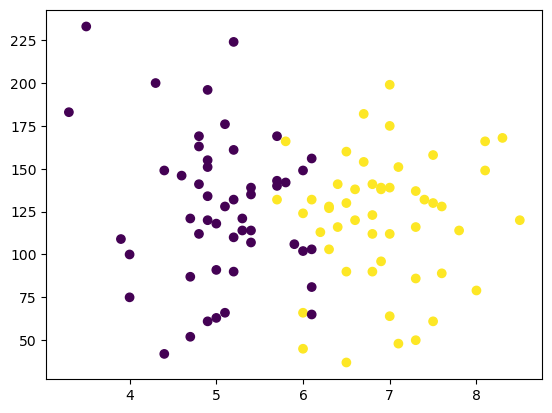

In [84]:
plt.scatter(df["cgpa"],df["iq"], c = df["placement"])


# Logistic Regression

**Logistic Regression** is a supervised machine learning algorithm used for classification problems — despite having "regression" in its name, it predicts categories (like yes/no, spam/not spam), not continuous numbers.

**Core idea:** It estimates the probability that a given input belongs to a particular class, using an S-shaped curve (the sigmoid function) to squeeze any output value into a range between 0 and 1. If the probability is above a threshold (usually 0.5), it's classified as one class; otherwise, the other.

# Extract input and output cols

In [20]:
# Inputs columns
x = df.iloc[:,0:2]


In [21]:
# Output columns
y = df.iloc[:,-1]

In [24]:
x


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [23]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split

In [34]:
train_test_split(x,y,test_size=0.1)

#x_train,x_test,y_train,y_test 
#Stored in this pattrer

[    cgpa     iq
 11   6.9  138.0
 30   7.6  128.0
 50   3.5  233.0
 62   6.0  102.0
 82   6.5   37.0
 ..   ...    ...
 71   6.1  132.0
 32   7.0  139.0
 63   6.3  128.0
 40   4.9  134.0
 1    5.9  106.0
 
 [90 rows x 2 columns],
     cgpa     iq
 27   6.0  124.0
 39   4.6  146.0
 41   5.4  114.0
 34   4.8  163.0
 29   7.0  112.0
 95   4.3  200.0
 72   7.3  116.0
 85   5.8  166.0
 79   6.5   90.0
 26   7.0  199.0,
 11    1
 30    1
 50    0
 62    0
 82    1
      ..
 71    1
 32    1
 63    1
 40    0
 1     0
 Name: placement, Length: 90, dtype: int64,
 27    1
 39    0
 41    0
 34    0
 29    1
 95    0
 72    1
 85    1
 79    1
 26    1
 Name: placement, dtype: int64]

In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

# Scale the values

In [35]:
from sklearn.preprocessing import StandardScaler

In [38]:
# Create object or varibale of standardScalar

scaler = StandardScaler()

In [40]:
# Transform 

x_train = scaler.fit_transform(x_train)

In [42]:
x_train

array([[-1.05272076, -0.28947362],
       [ 0.40209488, -0.18710574],
       [ 1.40228062,  0.88775702],
       [-0.96179478,  1.8602519 ],
       [ 0.03839097,  0.65742929],
       [-0.50716489, -0.23828968],
       [ 0.3111689 , -0.51980136],
       [-0.23438696,  1.1692687 ],
       [-0.77994282, -1.46670427],
       [-1.78012857, -1.23637653],
       [ 0.58394683, -0.08473786],
       [-0.59809087, -0.05914589],
       [-0.96179478, -1.59466412],
       [-0.50716489,  0.40150958],
       [ 1.40228062,  0.17118185],
       [-1.05272076,  1.01571688],
       [ 0.49302085, -2.20887141],
       [ 1.85691051, -1.13400865],
       [ 0.67487281,  0.78538914],
       [ 0.40209488,  0.45269352],
       [-0.8708688 , -0.1359218 ],
       [ 0.94765074,  0.40150958],
       [-1.14364673, -0.05914589],
       [-2.23475846,  2.80715481],
       [ 0.49302085, -0.85249697],
       [ 1.40228062, -1.59466412],
       [ 0.03839097, -0.54539333],
       [ 0.76579878,  0.45269352],
       [ 0.94765074,

In [43]:
x_test = scaler.transform(x_test)

In [44]:
x_test

array([[-0.8708688 , -0.826905  ],
       [-1.50735064,  1.96261979],
       [-1.14364673, -1.82499185],
       [ 0.94765074, -1.51788821],
       [-0.77994282,  1.34841249],
       [ 0.3111689 ,  0.11999791],
       [ 0.76579878, -0.00796195],
       [ 2.31154039, -0.08473786],
       [ 0.85672476,  0.37591761],
       [ 2.12968844,  1.14367673]])

In [ ]:
# Train the model using logistic regression

In [45]:
from sklearn.linear_model import LogisticRegression

In [50]:
# Create the object
clf = LogisticRegression()

#This object have all the power to access all the function in logistic regression class

In [51]:
# Model Training
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Evaluate the model 

In [52]:
clf.predict(x_test)

array([0, 0, 0, 1, 0, 1, 1, 1, 1, 1])

In [54]:
y_test

25    0
95    0
94    0
64    1
15    0
63    1
0     1
69    1
11    1
53    1
Name: placement, dtype: int64

In [55]:
# Now compare x test and y test.

In [56]:
y_pre = clf.predict(x_test)

In [57]:
from sklearn.metrics import accuracy_score

In [58]:
accuracy_score(y_test,y_pre)

1.0

In [67]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

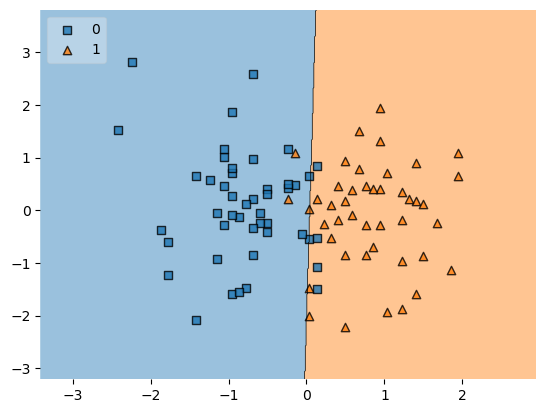

In [68]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [69]:
import pickle

In [70]:
pickle.dump(clf,open("model.pkl","wb"))